In [ ]:
# PCA Theory & Implementation

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_wine, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (7,5)
sns.set_style("whitegrid")
np.random.seed(42)

In [2]:
# Dataset 1 — Wine (13 features → high-dimensional)

wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names_wine = wine.feature_names

df_wine = pd.DataFrame(X_wine, columns=feature_names_wine)
print("Shape:", X_wine.shape)
df_wine.head()

Shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
# Mandatory scaling before PCA

scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

print("Before scaling - mean/std of first feature:", X_wine[:,0].mean().round(2), X_wine[:,0].std().round(2))
print("After scaling  - mean/std of first feature:", X_wine_scaled[:,0].mean().round(2), X_wine_scaled[:,0].std().round(2))

Before scaling - mean/std of first feature: 13.0 0.81
After scaling  - mean/std of first feature: 0.0 1.0


In [4]:
# Fit full PCA (keep all components) to inspect variance distribution

pca_full = PCA()
pca_full.fit(X_wine_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

for i, (ev, cv) in enumerate(zip(explained_var, cum_var), start=1):
    print(f"PC{i}: explained={ev:.3f}  cumulative={cv:.3f}")

PC1: explained=0.362  cumulative=0.362
PC2: explained=0.192  cumulative=0.554
PC3: explained=0.111  cumulative=0.665
PC4: explained=0.071  cumulative=0.736
PC5: explained=0.066  cumulative=0.802
PC6: explained=0.049  cumulative=0.851
PC7: explained=0.042  cumulative=0.893
PC8: explained=0.027  cumulative=0.920
PC9: explained=0.022  cumulative=0.942
PC10: explained=0.019  cumulative=0.962
PC11: explained=0.017  cumulative=0.979
PC12: explained=0.013  cumulative=0.992
PC13: explained=0.008  cumulative=1.000


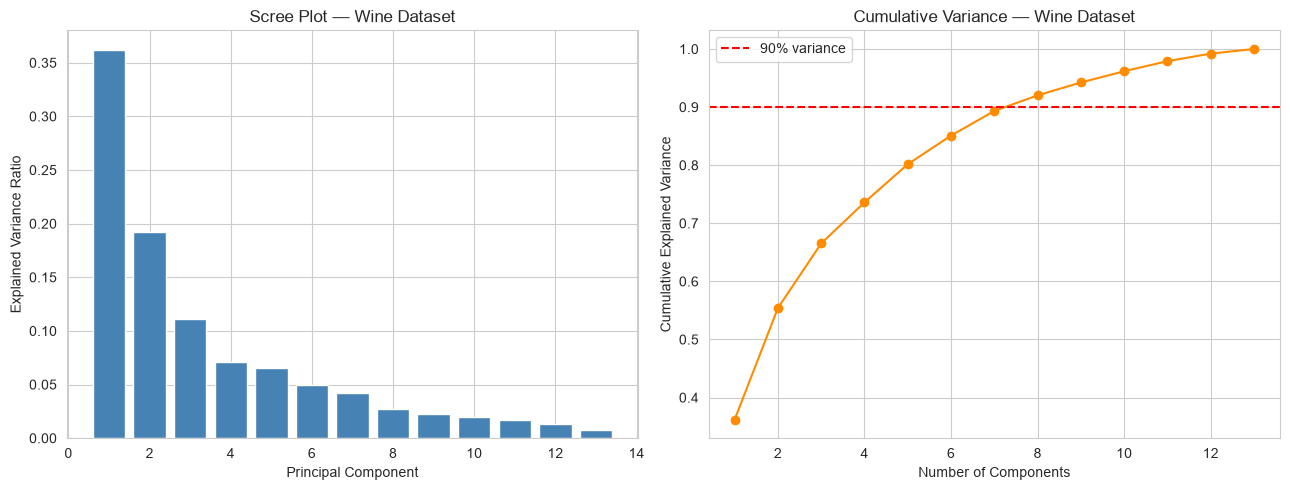

Components needed for 90% variance: 8


In [5]:
# Scree Plot

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].bar(range(1, len(explained_var)+1), explained_var, color='steelblue')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot — Wine Dataset")

axes[1].plot(range(1, len(cum_var)+1), cum_var, marker='o', color='darkorange')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% variance')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Variance — Wine Dataset")
axes[1].legend()

plt.tight_layout()
plt.show()

n_for_90 = int(np.argmax(cum_var >= 0.90) + 1)
print(f"Components needed for 90% variance: {n_for_90}")

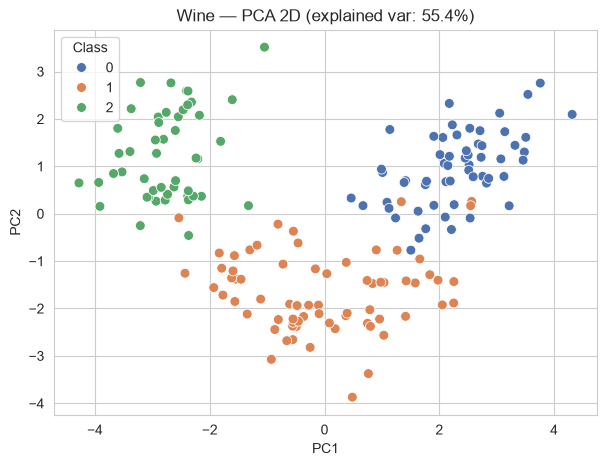

In [6]:
# Reduce to 2D and visualize

pca_2d = PCA(n_components=2)
X_wine_2d = pca_2d.fit_transform(X_wine_scaled)

df_2d = pd.DataFrame(X_wine_2d, columns=['PC1', 'PC2'])
df_2d['Class'] = y_wine.astype(str)

plt.figure(figsize=(7,5))
sns.scatterplot(data=df_2d, x='PC1', y='PC2', hue='Class', palette='deep', s=50)
plt.title(f"Wine — PCA 2D (explained var: {pca_2d.explained_variance_ratio_.sum():.1%})")
plt.show()

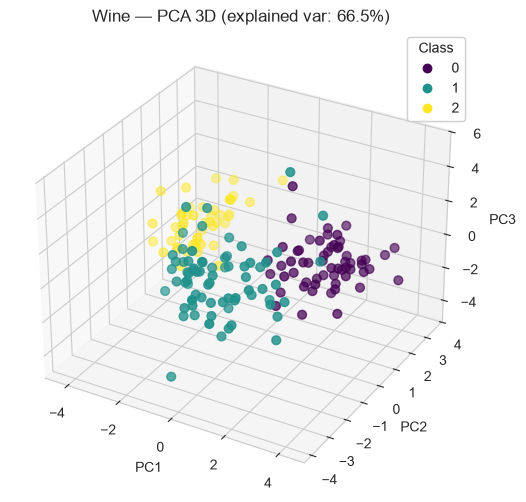

In [7]:
# Reduce to 3D and visualize

pca_3d = PCA(n_components=3)
X_wine_3d = pca_3d.fit_transform(X_wine_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_wine_3d[:,0], X_wine_3d[:,1], X_wine_3d[:,2], c=y_wine, cmap='viridis', s=40)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title(f"Wine — PCA 3D (explained var: {pca_3d.explained_variance_ratio_.sum():.1%})")
legend1 = ax.legend(*scatter.legend_elements(), title="Class")
ax.add_artist(legend1)
plt.show()

In [8]:
# Dataset 2 — Digits (64 features, higher dimensional)

digits = load_digits()
X_digits = digits.data
y_digits = digits.target
print("Shape:", X_digits.shape)

scaler_digits = StandardScaler()
X_digits_scaled = scaler_digits.fit_transform(X_digits)

Shape: (1797, 64)


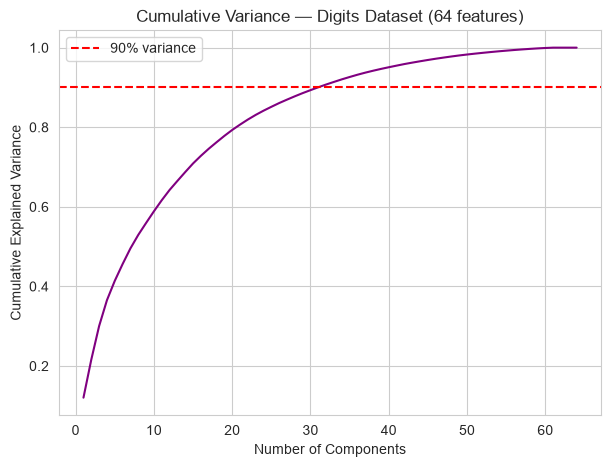

Components needed for 90% variance: 31 (out of 64 original features)


In [9]:
pca_digits_full = PCA()
pca_digits_full.fit(X_digits_scaled)
cum_var_digits = np.cumsum(pca_digits_full.explained_variance_ratio_)

plt.plot(range(1, len(cum_var_digits)+1), cum_var_digits, color='purple')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance — Digits Dataset (64 features)")
plt.legend()
plt.show()

n90 = int(np.argmax(cum_var_digits >= 0.90) + 1)
print(f"Components needed for 90% variance: {n90} (out of 64 original features)")

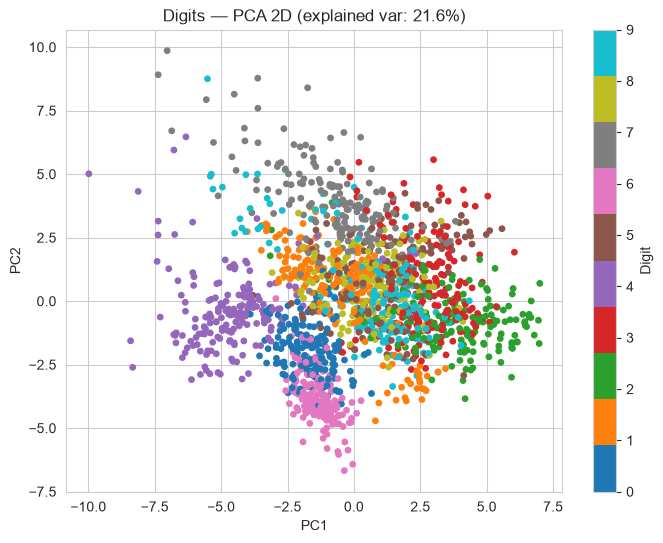

In [10]:
pca_digits_2d = PCA(n_components=2)
X_digits_2d = pca_digits_2d.fit_transform(X_digits_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_digits_2d[:,0], X_digits_2d[:,1], c=y_digits, cmap='tab10', s=15)
plt.colorbar(scatter, label='Digit')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f"Digits — PCA 2D (explained var: {pca_digits_2d.explained_variance_ratio_.sum():.1%})")
plt.show()